In [111]:
import numpy as np
import matplotlib.pyplot as plt
import csv

In [150]:
# URL = "https://statbase.org/data/sgp-bigmac-price/"


In [151]:
data = []

with open("data.csv","r") as f:
    reader = csv.reader(f)
    for row in reader:
        data.append(row)

rows = data[1:]
years, prices = zip(*rows) 

years = [int(y) for y in years]
prices = [float(p) for p in prices]

years = np.array(years)
x_mean, x_std = years.mean(), years.std()
x = (years - x_mean) / x_std
y = np.array(prices)


In [152]:
def cost_function(x, y, w, b):
    m = len(x)
    cost_sum = 0
    for i in range(m):
       y_hat = w * x[i] + b
       cost_sum += np.square(y_hat - y[i])
       total_cost = (1 / (2 * m)) * cost_sum
    return total_cost
        

In [153]:
def calculate_gradient(x, y, w, b):
    m = len(x)
    dC_dw = 0
    dC_db = 0
    for i in range(m):
        y_hat = w * x[i] + b
        
        dC_db += (y_hat - y[i])
        dC_dw += (y_hat - y[i]) * x[i]

    dC_db = (1 / m) * dC_db
    dC_dw = (1 / m) * dC_dw
    return dC_db, dC_dw

In [166]:
def gradient_descent(x, y, alpha, iterations):
    w = 0
    b = 0

    for i in range(iterations):
        dC_db, dC_dw = calculate_gradient(x, y, w, b)
        w = w - alpha * dC_dw
        b = b - alpha * dC_db
        
        if i % 50 == 0:
            print(f"Iteration {i} | Cost: {cost_function(x, y, w, b):.5f}")

    return w, b


In [168]:
alpha = 0.01
iterations = 500

final_w, final_b = gradient_descent(x, y, alpha, iterations)

Iteration 0 | Cost: 10.61662
Iteration 50 | Cost: 3.92266
Iteration 100 | Cost: 1.47245
Iteration 150 | Cost: 0.57560
Iteration 200 | Cost: 0.24732
Iteration 250 | Cost: 0.12716
Iteration 300 | Cost: 0.08317
Iteration 350 | Cost: 0.06708
Iteration 400 | Cost: 0.06118
Iteration 450 | Cost: 0.05903


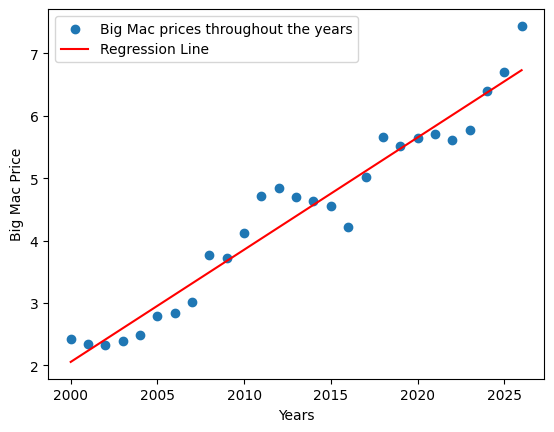

In [169]:
plt.scatter(years, y, label = "Big Mac prices throughout the years")

year_vals = np.linspace(min(years), max(years), 100)
x_vals_scaled = (year_vals - x_mean) / x_std
y_vals = final_w * x_vals_scaled + final_b
plt.plot(year_vals, y_vals, color = "red", label = "Regression Line")

plt.xlabel("Years")
plt.ylabel("Big Mac Price") 
plt.legend()
plt.show()

In [171]:
year = np.array(input("Input the year you want to predict: ")).astype(float)

def predict(year, w, b, x_mean, x_std):
    x_scaled = (year - x_mean) / x_std
    return w * x_scaled + b

print(predict(year, final_w, final_b, x_mean, x_std))

11.04590317508206
